# Загрузка и анализ данных

Скачаем небходимые библиотеки

In [ ]:
!pip install -q catboost category-encoders econml optuna sentence-transformers transformers umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 644.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 14.3 MB/s eta 0:00:00


Загрузим необходимые билиотеки

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from transformers import pipeline
from sentence_transformers import SentenceTransformer

from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from optuna import create_study
from optuna.samplers import TPESampler
from optuna.logging import set_verbosity, WARNING

from catboost import CatBoostRegressor
from category_encoders import CatBoostEncoder

from econml.dml import NonParamDML

from collections import Counter
from itertools import chain

import torch

from tqdm.auto import tqdm

random_state = 42

Загрузим датасет

Для нашей задачи динамического ценообразования мы будем в дальнейшем по признакам предсказывать количество приобретённых товаров

In [ ]:
df = pd.read_csv('online_retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Посмотрим на распределение покупателей по странам

In [ ]:
df['Country'].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


Посмотрим, в скольких объектах количество приобретённых товаров отрицательное

In [ ]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Оказывается есть больше 10000 отменённых покупок

Посчитаем, для скольких объектов для каждого признака пропущены объекты

In [ ]:
df.isna().sum(axis=0)

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Видим, что примерно треть номеров покупателей отсутствует, есть очень мало пропусков у описания, у других же признаков нет пропусков вообще

Итак, удалим некоторые строки в датасете:
1. Оставим только покупателей из Великобритании, их в датасете около 90%
2. Удалим те строки, где номер покупки не численный
3. Удалим те строки, где количество приобретённых товаров меньше 0
4. Удалим те строки, где описание отсутствует или не равно ему же в низком регистре
5. Удалим те строки, в которых первый символ кода товара не числовой

In [ ]:
df = df[df['Country'] == 'United Kingdom'].drop(columns='Country')
df = df.drop(df[~df['InvoiceNo'].str.isnumeric()].index)
df = df.drop(df[df['Quantity'] < 0].index)
df = df.drop(df[df['Description'].isna()].index)
df = df.drop(df[df['Description'].str.lower() == df['Description']].index)
df = df[df['StockCode'].str[0].str.isnumeric()]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0
...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0


Удалим у названий пробелы слева и справа, а также понизим его регистр

In [ ]:
df['Description'] = df['Description'].str.lstrip().str.rstrip().str.lower()
descriptions = np.sort(df['Description'].unique())
descriptions

array(['*boombox ipod classic', '*usb office mirror ball',
       '10 colour spaceboy pen', ..., 'zinc willie winkie  candle stick',
       'zinc wire kitchen organiser', 'zinc wire sweetheart letter tray'],
      dtype=object)

## Кластеризация описаний товаров

Определим девайс, на котором будет проходить извлечение эмюбеддингов

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Загрузим трансформер

In [ ]:
sentence_transformer = SentenceTransformer('BAAI/bge-small-en-v1.5').to(device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Получим эмбеддинги описаний товаров

In [ ]:
%%time
descriptions_encoded = sentence_transformer.encode(
    descriptions,
    batch_size=1024,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 793 ms, sys: 167 ms, total: 960 ms
Wall time: 3.26 s


Итак, мы получили эмбеддинги - но их размерность (384) чересчур велика для алгоритма кластеризации, поэтому пайплайн работы следующий:
1. Сначала пространство сжимается с помощью UMAP (рекомендуют на кластеризации текстов чтобы новая размерность равнялась 5-15), который хорошо сохраняет локальную структуру данных
2. Потом на сжатых данных применяется алгоритм кластеризации HDBSCAN, который выделяет не только устойчивые плотные кластеры, но и шумовые точки

In [ ]:
class ReducerClusterer:
    def __init__(self, umap_kwargs, hdbscan_kwargs):
        self.umap = UMAP(**umap_kwargs)
        self.hdbscan = HDBSCAN(**hdbscan_kwargs)

    def fit_transform(self, X):
        X_reduced = self.umap.fit_transform(X)
        cluster_labels = self.hdbscan.fit_predict(X_reduced)
        return X_reduced, cluster_labels

Пока используем наш пайплайн для визуализации кластеров на двумерной плоскости

Здесь у UMAP было выбрано достаточно большое число соседей n_neighbors в исходном пространстве, чтобы алгоритм обращал внимание ещё и на глобальную структуру, а также малое значение минимального расстояния между точками в низкорамзерной проекции чтобы образовывались чётко разделённые "сжатые" кластеры

Также стоит отметить, что в качестве метрики алгоритма UMAP вместо евклидового расстояния, которое сильно обращает внимание на шум, было выбрано косинусное

In [ ]:
%%time
rc_2d = ReducerClusterer(
    {
        'n_neighbors': 50,
        'n_components': 2,
        'min_dist': 0.001,
        'metric': 'cosine',
        'random_state': random_state
    },
    {
        'min_cluster_size': 30
    }
)
descriptions_reduced, cluster_labels_2d = rc_2d.fit_transform(
    descriptions_encoded
)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 54.2 s, sys: 366 ms, total: 54.5 s
Wall time: 1min 51s


Напишем функцию для визуализации дендрограммы

In [ ]:
def plot_condensed_tree(model, log_size=True, figsize=(15, 10)):
    ax = plt.subplots(figsize=figsize)[1]
    model.hdbscan.condensed_tree_.plot(axis=ax, log_size=log_size)
    plt.show()

Визуализируем дендрограмму

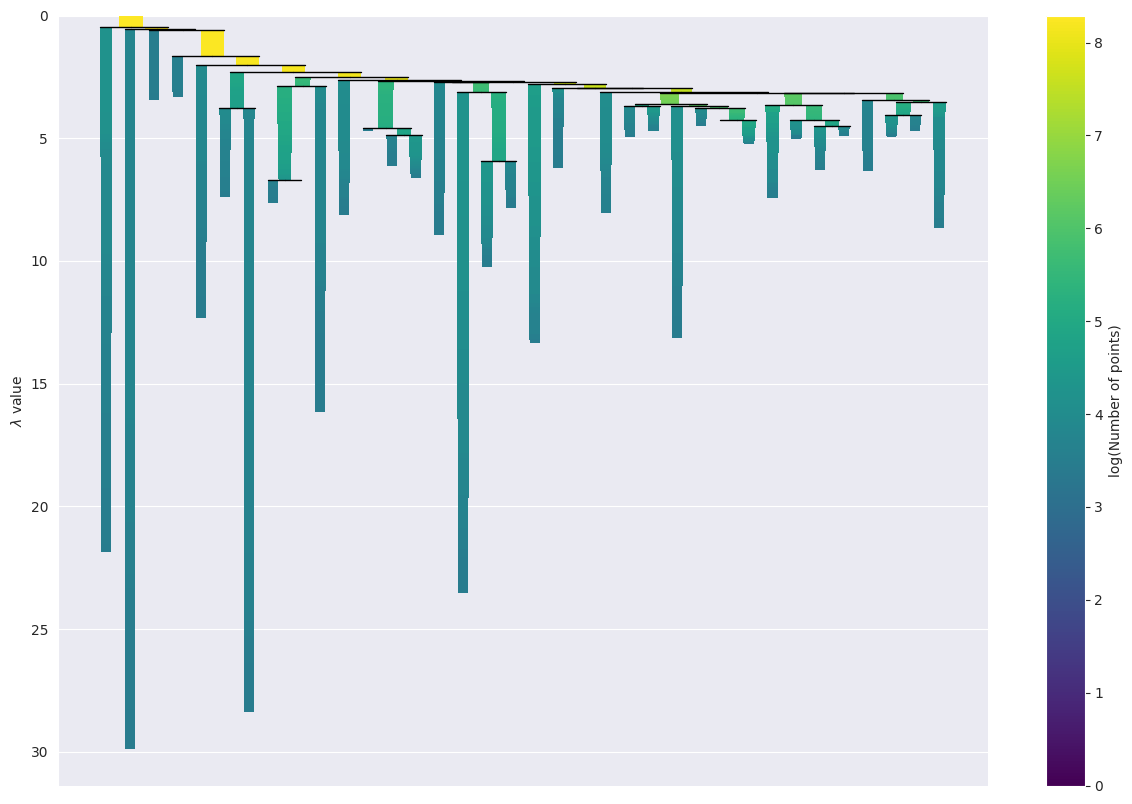

In [ ]:
plot_condensed_tree(rc_2d)

На этой дендрограмме каждая ветвь дерева соответствует кластеру на определенном уровне плотности. Длинные ветви отражают более устойчивые кластеры (существующие в широком диапазоне плотностей), короткие ветви — это менее устойчивые структуры, которые могут исчезать при небольшом изменении параметров плотности

Напишем функцию для визуализации двумерных кластеров

In [ ]:
def plot_embeddings_2d(
    embeddings_2d,
    cluster_labels,
    cmap='tab20',
    s=5,
    alpha=0.7,
    figsize=(15, 12)
):
    ax = plt.subplots(figsize=figsize)[1]
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=cluster_labels,
        cmap=cmap,
        s=s,
        alpha=alpha
    )
    plt.colorbar(scatter, label='Cluster')
    plt.title('UMAP + HDBSCAN')
    plt.xlabel('Компонента 1')
    plt.ylabel('Компонента 2')
    plt.show()

Визуализиурем двумерные кластеры

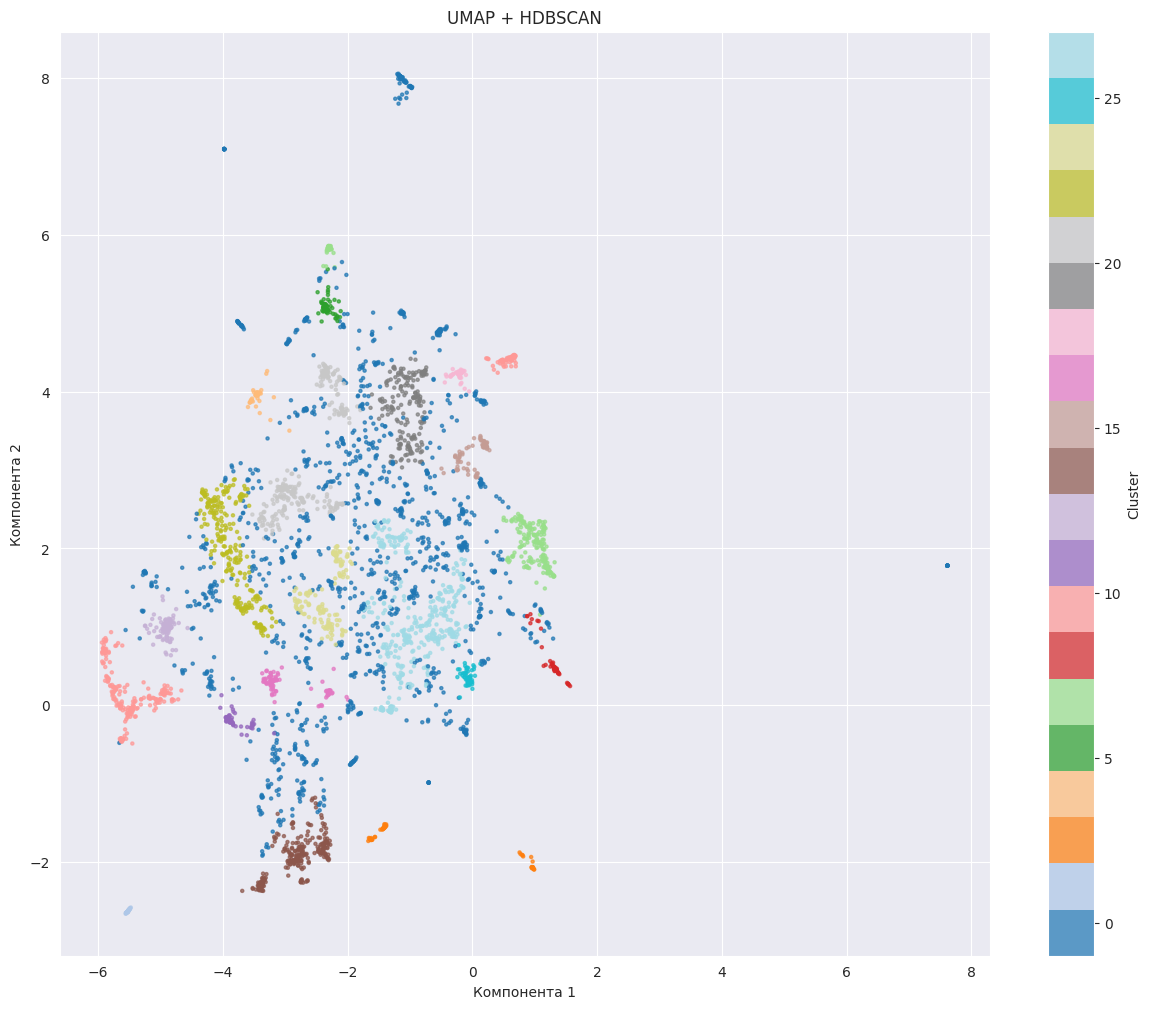

In [ ]:
plot_embeddings_2d(descriptions_reduced, cluster_labels_2d)

Видим, что образовалось одно облако с редкими выбросами. Впрочем, у этого облака в разных областях разные плотности, в более плотных областях и образуются кластеры

Теперь получим снова кластеры, однако новое пространство имеет размерность не 2, а 15

In [ ]:
%%time
rc = ReducerClusterer(
    {
        'n_neighbors': 50,
        'n_components': 15,
        'min_dist': 0.001,
        'metric': 'cosine',
        'random_state': random_state
    },
    {
        'min_cluster_size': 30
    }
)
descriptions_reduced, cluster_labels = rc.fit_transform(descriptions_encoded)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 38.6 s, sys: 145 ms, total: 38.7 s
Wall time: 38.9 s


In [ ]:
np.unique(cluster_labels).shape[0]

30

Всего получилось 30 кластеров

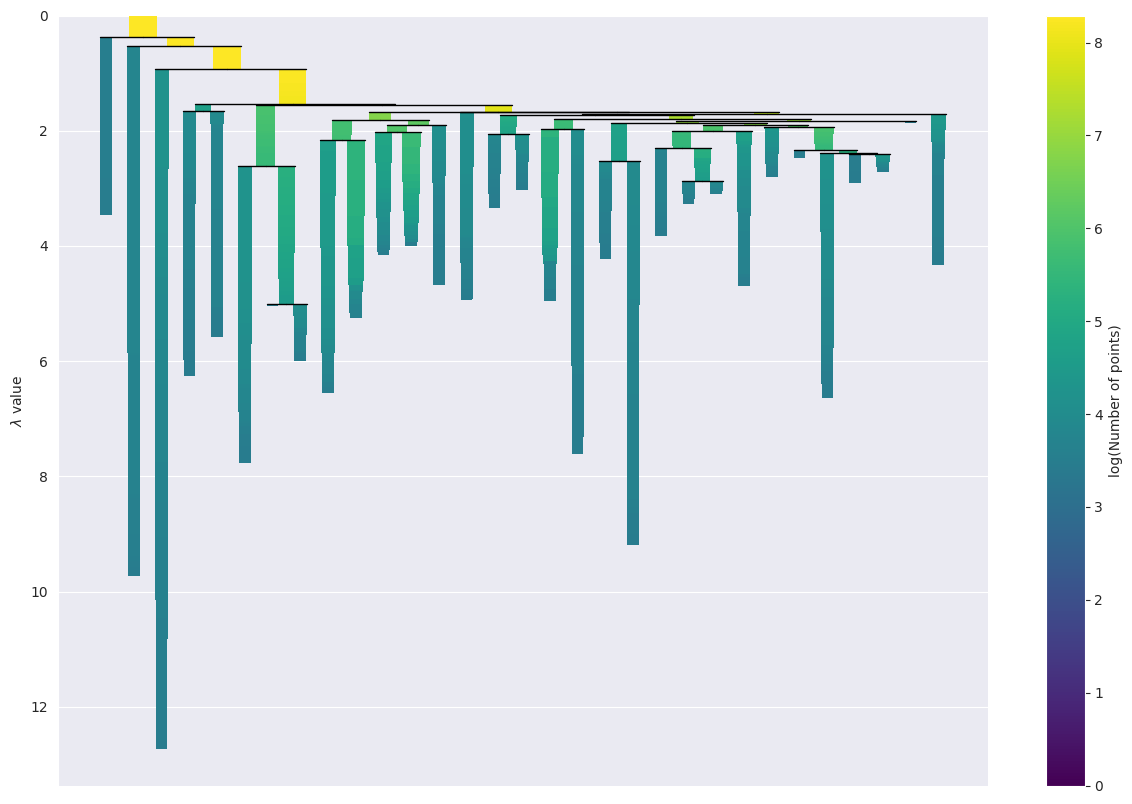

In [ ]:
plot_condensed_tree(rc)

Видим, что здесь образуются менее плотные кластеры, чем в двумерном случае

А теперь сделаем ход конём - попросим LLM для каждого кластера придумать информативное название. Во-первых, это позволит понять, какие товары попали в каждый кластер, а во вторых, позволит по названиями кластеров понять, какие кластеры похожи друг на друга и которые можно объединить друг с другом

Загрузим пайплайн с генерацией текстов. В качестве базовой легковесной модели будет выступать Qwen

In [ ]:
pipe = pipeline(
    'text-generation',
    model='Qwen/Qwen2.5-1.5B-Instruct',
    dtype=torch.bfloat16 if device == 'cuda' else torch.float32,
    device_map=device
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Получим функцию для генерации имени кластера, при этом гиперпараметры генерации (температуру) сделаем такими, чтобы модель не особо фантазировала, а выдавала детерминированные ответы

In [ ]:
def generate_cluster_name(
    ngram_scores,
    max_ngrams=None,
    max_new_tokens=15,
    temperature=0.1
):
    max_ngrams = max_ngrams or len(ngram_scores)
    formatted_ngrams = ', '.join(
        [f"'{gram}' ({score:.3f})" for gram, score in ngram_scores[:max_ngrams]]
    )
    messages = [
        {
            'role': 'system',
            'content': (
                'You are an expert E-commerce Product Categorizer. ' +
                'Your job is to generate a concise, 2-5 word category name ' +
                'based on top N-grams of a product cluster. ' +
                'Return ONLY the category name, without quotes, ' +
                'explanations,or introductory text.'
            )
        },
        {
            'role': 'user',
            'content': f'Top N-grams: {formatted_ngrams}\nCategory Name:'
        }
    ]
    outputs = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=False,
        return_full_text=False
    )
    return outputs[0]['generated_text'].strip()

Итак, для каждого уникального названия кластера соберём эмбеддинги

In [ ]:
descriptions_per_clusters = {}
for description, label in zip(descriptions, cluster_labels):
    if label not in descriptions_per_clusters.keys():
        descriptions_per_clusters[label] = []
    descriptions_per_clusters[label].append(description)

Для каждого кластера с помощью TF-IDF определим наиболее частые уни-, би- и триграммы и подадим на вход LLM, чтобы онапо ним придумала информативое имя кластера

In [ ]:
cluster_names = {}
for label, texts in tqdm(descriptions_per_clusters.items()):
    if label == -1:
        cluster_names[label] = 'Noise cluster'
    else:
        tf_idf = TfidfVectorizer(ngram_range=(1, 3), stop_words='english')
        dense = pd.DataFrame(
            tf_idf.fit_transform(texts).todense(),
            columns=tf_idf.get_feature_names_out()
        )
        mean_by_ngrams = dense.mean(axis=0).sort_values(ascending=False)
        cluster_ngrams = list(zip(mean_by_ngrams.index, mean_by_ngrams.values))
        name = generate_cluster_name(cluster_ngrams, max_ngrams=50)
        cluster_names[label] = name

  0%|          | 0/30 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Посмотрим на имена кластеров, которые "выдумала" LLM

In [ ]:
cluster_names

{np.int64(-1): 'Noise cluster',
 np.int64(4): 'Mirror Category',
 np.int64(23): 'Pencils & Accessories',
 np.int64(12): 'Easter Decorations',
 np.int64(20): 'Christmas Cards',
 np.int64(13): 'Christmas Decorations',
 np.int64(24): 'Cake Accessories',
 np.int64(15): 'Cabinet Organizer',
 np.int64(10): 'Candle Set Holder',
 np.int64(8): 'Space Cadets',
 np.int64(22): 'Gift Wrap Set',
 np.int64(19): 'Birthday Cards',
 np.int64(6): 'Necklace Category',
 np.int64(16): 'Gift Bag',
 np.int64(3): 'Wall Art',
 np.int64(21): 'Treasure Box',
 np.int64(7): 'Notebook Set',
 np.int64(9): 'Light Holder',
 np.int64(2): 'Metal Sign',
 np.int64(1): 'Kitchen Wall Clock',
 np.int64(5): 'Earrings',
 np.int64(27): 'Glass Storage Jar',
 np.int64(11): 'Photo Frame Category',
 np.int64(26): 'Office Mug & Accessories',
 np.int64(0): 'Key Accessories',
 np.int64(25): 'Red Retro Spot Kitchen Items',
 np.int64(17): 'Passport Cover',
 np.int64(18): 'Hot Water Bottle',
 np.int64(28): 'Teaware',
 np.int64(14): 'Doorm

Виидим, что некоторые кластеры можно объединить в одну группу, для этого составим словарь замен

In [ ]:
cluster_name_map = {
    'Mirror Category': 'Household Items',
    'Pencils & Accessories': 'Stationery',
    'Easter Decorations': 'Decorations',
    'Christmas Cards': 'Gifts',
    'Christmas Decorations': 'Decorations',
    'Cake Accessories': 'Accessories',
    'Stationery Set': 'Stationery',
    'Cabinet Organizer': 'Household Items',
    'Candle Set Holder': 'Household Items',
    'Space Cadets': 'Gifts',
    'Gift Wrap Set': 'Gifts',
    'Birthday Cards': 'Gifts',
    'Necklace Category': 'Jewelry',
    'Gift Bag': 'Gifts',
    'Wall Art': 'Household Items',
    'Treasure Box': 'Gifts',
    'Notebook Set': 'Household Items',
    'Light Holder': 'Household Items',
    'Metal Sign': 'Accessories',
    'Kitchen Wall Clock': 'Household Items',
    'Earrings': 'Jewelry',
    'Glass Storage Jar': 'Household Items',
    'Photo Frame Category': 'Accessories',
    'Office Mug & Accessories': 'Accessories',
    'Key Accessories': 'Accessories',
    'Red Retro Spot Kitchen Items': 'Accessories',
    'Passport Cover': 'Accessories',
    'Hot Water Bottle': 'Household Items',
    'Teaware': 'Household Items',
    'Doormats & Accessories': 'Accessories'
}

Объединим некоторые кластеры

In [ ]:
for name in cluster_names.keys():
    if cluster_names[name] in cluster_name_map.keys():
        cluster_names[name] = cluster_name_map[cluster_names[name]]

Визуализируем новые именак кластеров

In [ ]:
cluster_names

{np.int64(-1): 'Noise cluster',
 np.int64(4): 'Household Items',
 np.int64(23): 'Stationery',
 np.int64(12): 'Decorations',
 np.int64(20): 'Gifts',
 np.int64(13): 'Decorations',
 np.int64(24): 'Accessories',
 np.int64(15): 'Household Items',
 np.int64(10): 'Household Items',
 np.int64(8): 'Gifts',
 np.int64(22): 'Gifts',
 np.int64(19): 'Gifts',
 np.int64(6): 'Jewelry',
 np.int64(16): 'Gifts',
 np.int64(3): 'Household Items',
 np.int64(21): 'Gifts',
 np.int64(7): 'Household Items',
 np.int64(9): 'Household Items',
 np.int64(2): 'Accessories',
 np.int64(1): 'Household Items',
 np.int64(5): 'Jewelry',
 np.int64(27): 'Household Items',
 np.int64(11): 'Accessories',
 np.int64(26): 'Accessories',
 np.int64(0): 'Accessories',
 np.int64(25): 'Accessories',
 np.int64(17): 'Accessories',
 np.int64(18): 'Household Items',
 np.int64(28): 'Household Items',
 np.int64(14): 'Accessories'}

Определим косинусную разность названий кластеров

In [ ]:
unique_cluster_names = np.unique(list(cluster_names.values()))
cluster_names_encoded = sentence_transformer.encode(
    unique_cluster_names,
    batch_size=1,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Визуализируем значения метрик

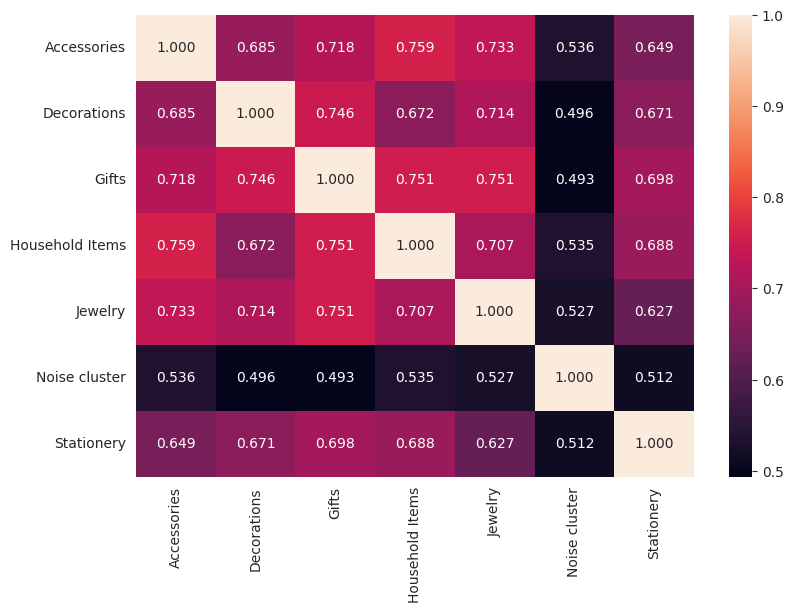

In [ ]:
ax = plt.subplots(figsize=(9, 6))[1]
sns.heatmap(
    cosine_similarity(cluster_names_encoded),
    annot=True,
    fmt='.3f',
    xticklabels=unique_cluster_names,
    yticklabels=unique_cluster_names,
    ax=ax
)
plt.show()

Видим довольно высокую корреляцию в следующих парах:
1. Подарки-"Ювелириные украшения"
2. "Домашняя утварь"-Аксессуары
3. Подарки-Декораторы

Заменим номера кластеров на их названия

In [ ]:
replace_map = dict(
    zip(descriptions, np.vectorize(cluster_names.get)(cluster_labels))
)

Изменим название признака с описания на каиегорию

In [ ]:
df['Description'] = df['Description'].replace(replace_map)
df = df.rename(columns={'Description': 'Category'})

## Выделение дат

Превратим тип признака в дату

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Определим, является ли день праздником (в праздники цена может очень сильно меняться):
1. 25 декабря 2010 года - Рождество
2. 26 декабря 2010 года - Boxing day
3. 31 декабря 2010 года и 1 января 2011 года - Новый Год
4. 14 февраля 2011 года - день влюблённых
5. 3 апреля 2011 года - Страстная пятница
6. 22 апреля - 25 апреля 2011 года - Пасха

In [ ]:
df.insert(df.columns.get_loc('InvoiceDate') + 1, 'IsInvoiceDateHoliday', 0)
df.loc[
    df[df['InvoiceDate'].dt.date.isin([
        pd.to_datetime('2010-12-25').date(),
        pd.to_datetime('2010-12-26').date(),
        pd.to_datetime('2010-12-31').date(),
        pd.to_datetime('2011-01-01').date(),
        pd.to_datetime('2011-02-14').date(),
        pd.to_datetime('2011-04-03').date(),
        pd.to_datetime('2011-04-22').date(),
        pd.to_datetime('2011-04-23').date(),
        pd.to_datetime('2011-04-24').date(),
        pd.to_datetime('2011-04-25').date()
    ])].index,
    'IsInvoiceDateHoliday'
] = 1

Теперь для каждого дня определим, является ли он выходным

In [ ]:
df.insert(
    df.columns.get_loc('IsInvoiceDateHoliday') + 1,
    'IsInvoiceDateWeekend',
    0
)
df.loc[
    df[df['InvoiceDate'].dt.weekday.isin([5, 6])].index,
    'IsInvoiceDateWeekend'
] = 1

Сначала трансформируем количество пройденных минут с начала дня (то есть время дня по сути) по формуле:
$$\large{min \leftarrow \sin\left(\frac{\pi\cdot min}{1800}\right)}$$

Теперь трансформируем номер месяца - по следующей формуле:
$$\large{mon \leftarrow \sin\left(\frac{\pi\cdot mon}{6}\right)}$$

Логика здесь такая, чтобы соседние временные отрезки имели близкие похожие значения

In [ ]:
df.insert(
    df.columns.get_loc('InvoiceDate') + 1,
    'SinMonth',
    np.sin(np.pi * df['InvoiceDate'].dt.month / 6)
)
df.insert(
    df.columns.get_loc('InvoiceDate') + 1,
    'SinMinute',
    np.sin(
         np.pi * \
        (df['InvoiceDate'].dt.hour * 60 + df['InvoiceDate'].dt.minute) / 1800
    )
)

Напишем функцию для визуализации количества покупок в зависимости от временных отрезков

In [ ]:
def barplot_time(column, time, palette='RdBu', figsize=(12, 6)):
    ax = plt.subplots(figsize=figsize)[1]
    statistics = getattr(column.dt, time).value_counts()
    sns.barplot(statistics, palette=palette, ax=ax)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xlabel(f'Invoice{time.capitalize()}')
    plt.show()

Визуализируем количество покупок в завимисоти от часа

/tmp/ipykernel_2400/1073692895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


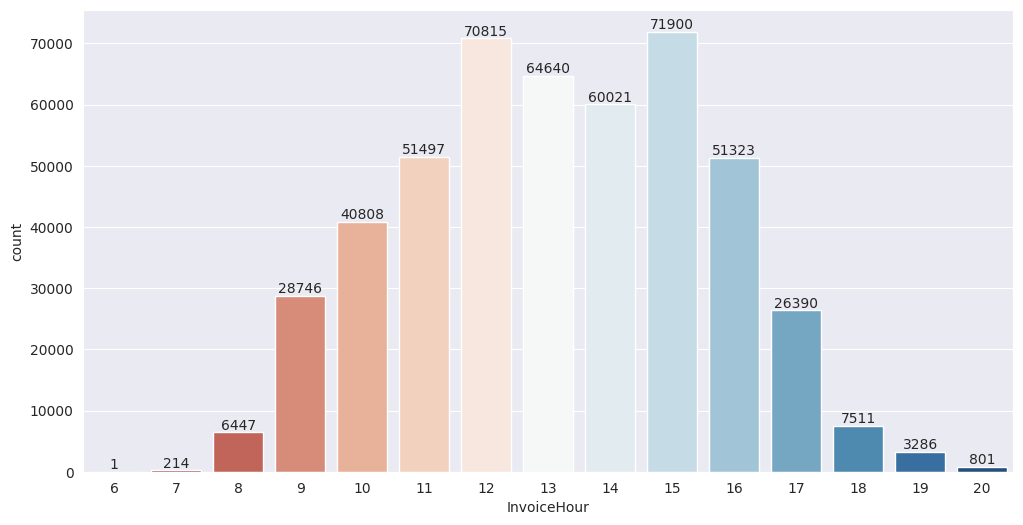

In [ ]:
barplot_time(df['InvoiceDate'], 'hour')

Визуализируем количество покупок в завимисоти от месяца

/tmp/ipykernel_2400/1073692895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


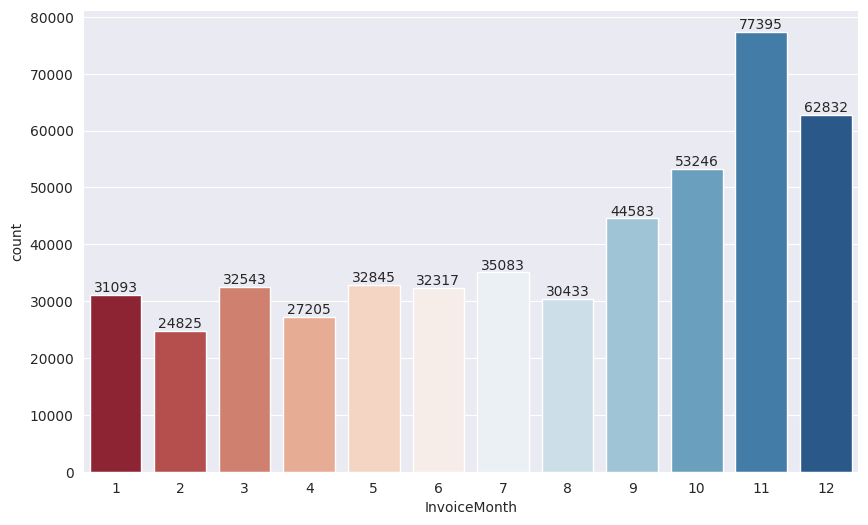

In [ ]:
barplot_time(df['InvoiceDate'], 'month', figsize=(10, 6))

Итак, посчитаем количество покупок попарно по месяцам и часам

In [ ]:
counts = np.zeros((24, 12)).astype(int)
for _, x in tqdm(df.iterrows()):
    counts[x['InvoiceDate'].hour][x['InvoiceDate'].month - 1] += 1
counts = pd.DataFrame(counts, columns=range(1, 13))

0it [00:00, ?it/s]

Визуализируем посчитанную матрицу

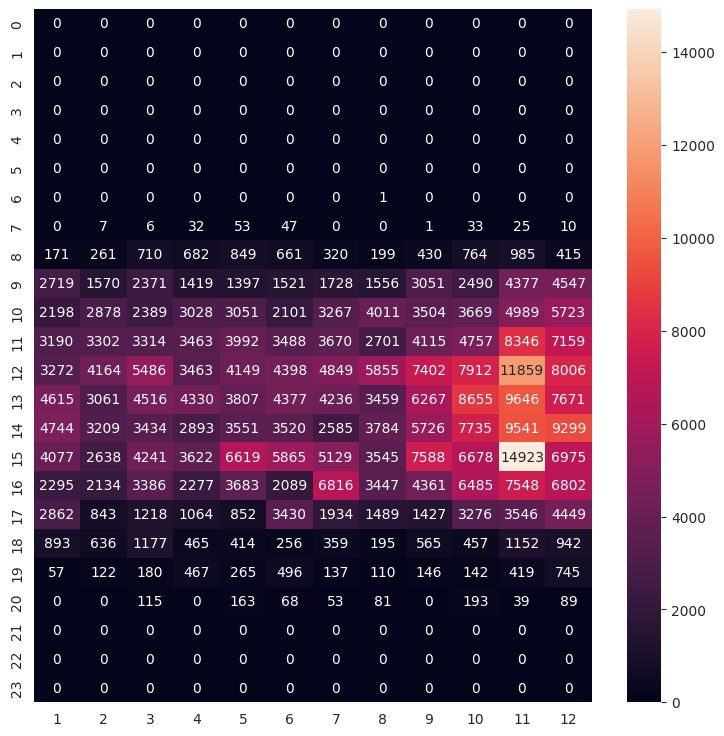

In [ ]:
ax = plt.subplots(figsize=(9, 9))[1]
sns.heatmap(counts, annot=True, fmt='d', ax=ax)
plt.show()

Замечаем следующее:
- Все покупки осуществляется в основном с 8 утра до 9 вечера
- Больше всего покупок совершалось осенью и ранней зимой

Итак, удалим признак даты

In [ ]:
df = df.drop(columns='InvoiceDate')

## Препроцессинг признаков

Посмотрим, сколько процентов значений в признаке CustomerID пропушено

In [ ]:
df[df['CustomerID'].isna()].shape[0] / df.shape[0]

0.26918868703550786

Итак, почти 27%. Сделаем вот что - распределим пропущенные значения случайно по уже имеющимся номерам заказов

In [ ]:
df.loc[df[df['CustomerID'].isna()].index, 'CustomerID'] = np.random.choice(
    np.unique(df[~df['CustomerID'].isna()]['CustomerID']),
    df[df['CustomerID'].isna()].shape[0]
)
df['CustomerID'] = df['CustomerID'].astype(int)

Удалим следующие объекты:
- Там, где количество приобретённых товаров больше 10000
- Там, где цена неположительная

In [ ]:
df = df.drop(df[df['Quantity'] > 10000].index)
df = df.drop(df[df['UnitPrice'] <= 0].index)

Разделим выборку на тренировочную, валидационную и тестовую выборки

In [ ]:
df_train_and_valid, df_test = train_test_split(
    df,
    stratify=df['Category'],
    test_size=0.25
)
df_train, df_valid = train_test_split(
    df_train_and_valid,
    stratify=df_train_and_valid['Category'],
    test_size=0.25
)

Выделим предикторы и целевую переменную

In [ ]:
X_train, y_train = df_train.drop(columns='Quantity'), df_train['Quantity']
X_valid, y_valid = df_valid.drop(columns='Quantity'), df_valid['Quantity']
X_test, y_test = df_test.drop(columns='Quantity'), df_test['Quantity']

Получим категориальные столбцы

In [ ]:
categorical_features = ['InvoiceNo', 'StockCode', 'Category', 'CustomerID']

# Обучение моделей

Напишем функция для рассчёта 2 показателей:
1. Среднее увеличение выручки
2. Медиана процентного увеличения выручки

In [ ]:
def calculate_revenue_stats(df, epsilon=1e-9):
    s1 = df['UnitPrice'] * df['Quantity']
    s2 = df['OriginalUnitPrice'] * df['OriginalQuantity']
    return (
        (s1 - s2).mean().item(),
        np.nanmedian((s1 - s2) / (s2 + epsilon) * 100).item()
    )

С помощью этой функции будут визуализиоваться 2 графика:
1. Точечный график зависимости цены от количества приобретённых товаров для оригинальных и предсказанных значений
2. Точечный график зависимости цены от выручки для оригинальных и предсказанных значений

In [ ]:
def plot_financial_plots(df, figsize=(18, 6)):
    axis = plt.subplots(ncols=2, figsize=figsize)[1]
    axis[0].scatter(
        df['OriginalUnitPrice'],
        df['OriginalQuantity'],
        color='red',
        label='Истинные значения'
    )
    axis[0].scatter(
        df['UnitPrice'],
        df['Quantity'],
        color='blue',
        label='Предсказания'
    )
    axis[0].set_ylabel('Количество')
    axis[0].set_title('Точечный график зависимости количества от цены')

    axis[1].scatter(
        df['OriginalUnitPrice'],
        df['OriginalUnitPrice'] * df['OriginalQuantity'],
        color='red',
        label='Истинные значения'
    )
    axis[1].scatter(
        df['UnitPrice'],
        df['UnitPrice'] * df['Quantity'],
        color='blue',
        label='Предсказания'
    )
    axis[1].set_ylabel('Выручка')
    axis[1].set_title('Точечный график зависимости выручки от цены')

    for ax in axis:
        ax.set_xlabel('Цена')
        ax.legend()
    plt.show()

## CatBoost

Первый способ, который мы испробуем - выучить модель предсказывать по признакам количество приобретённого товара, а потом сформировать сетку цен-кандидатов и выбрать ту цену, при которой выручка (произведение цены и предсказанного количества максимальна)

Будем подбирать на валидационной выборке оптимальные гиперпараметры, в качестве оптимизируемой метрики выберем RMSLE (root mean squared log error):

$$\large{\mathcal{L}(y,\hat{y})=\sqrt{\frac{1}{N}\sum_{i=1}^N \log\left(\frac{y + 1}{\hat{y} + 1}\right)^2}}$$

Особенность этой метрики заключается в том, что за недопрогноз она штрафует сльнее, чем за перепрогноз

Итак, 2 следующие функции предназначены для подбора оптимальных гиперпараметров для модели CatBoost

In [ ]:
def objective_catboost(trial, **default_params):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    model = CatBoostRegressor(**param_distributions, **default_params)
    model.fit(X_train, y_train, cat_features=categorical_features)
    value = mean_squared_log_error(
        y_valid,
        np.clip(model.predict(X_valid), a_min=1, a_max=np.inf)
    )
    return value

def optimize_catboost(n_trials=20, **default_params):
    study = create_study(
        direction='minimize',
        sampler=TPESampler(seed=random_state),
        study_name=f'Оптимизация алгоритма CatBoost'
    )
    set_verbosity(WARNING)
    study.optimize(
        lambda trial: objective_catboost(trial, **default_params),
        show_progress_bar=True,
        n_trials=n_trials
    )
    model = CatBoostRegressor(**study.best_params, **default_params)
    model.fit(X_train, y_train, cat_features=categorical_features)
    return model

Получим модель с оптимальными гиперпараметрами

In [ ]:
catboost_model = optimize_catboost(
    n_trials=20,
    verbose=False,
    random_state=random_state,
    monotone_constraints={'UnitPrice': -1}
)

[I 2026-09-02 17:11:35,893] A new study created in memory with name: Оптимизация алгоритма CatBoost


  0%|          | 0/20 [00:00<?, ?it/s]

А сейчас начнём формировать сетку цен-кандидатов для каждого объекта из тестовой выборки по следующему правилу:
1. Для объекта из тестовой выборки собираем все уникальные цены из тренировочной и валидационной выборок с таким же кодом товара
2. Если же ни в тренировочной, ни валидационной выборках объекта с данным кодом товара нет, то ставим среднюю цену по всем объектам из объединения тренировочной и валидационной выборках

In [ ]:
%%time
prices = {
    key: np.sort(
        np.unique(
            np.concatenate([
                X_train[X_train['StockCode'] == key]['UnitPrice'],
                X_valid[X_valid['StockCode'] == key]['UnitPrice']
            ])
        )
    ) for key in np.sort(X_test['StockCode'].unique())
}

unit_price_mean = round(
    pd.concat([X_train, X_valid])['UnitPrice'].mean().item(),
    2
)
for key, value in prices.items():
    if len(value) == 0:
        prices[key] = np.array([unit_price_mean])

CPU times: user 1min 29s, sys: 27.5 ms, total: 1min 29s
Wall time: 1min 30s


Далее для каждой цены из списка цен для объекта составляем сетку следующим образом - умножаем цену на каждое значение из списка процента (в моём случае по умолчанию список равняется $\large{[0.8, 0.85, 0.9, 0.95, 1, 1.05, 1.1, 1.15, 1.2]}$) и таким образом формируется финальный список

Выбирается цена, для котороый выручка (произведение цены на предсказанное количества приобретаемых товаров при данной цене) максимально

Итак, напишем функцию для нахождения оптимальной цены при данных признаках для каждого объекта

In [ ]:
def predict_optimal_price_catboost(
    sample,
    catboost_model,
    percents=np.arange(0.8, 1.25, 0.05)
):
    local_prices = prices[sample['StockCode'].values[0]]
    new_prices = np.unique(np.sort(np.array(list(
        chain.from_iterable([
            np.round(price * percents, 2) for price in local_prices
        ])
    ))))
    candidates = sample.apply(lambda x: np.tile(x, new_prices.shape[0]))
    candidates['UnitPrice'] = new_prices
    quantity = catboost_model.predict(candidates)
    revenue = quantity * candidates['UnitPrice']
    idxmax = revenue.idxmax()
    return quantity[idxmax].item(), new_prices[idxmax].item()

Итак, найдём оптимальную ценук для каждого объекта

In [ ]:
df_test_with_optimal_prices_catboost = df_test.copy()
quantities, optimal_prices = [], []
for i in tqdm(range(X_test.shape[0])):
    quantity, optimal_price = predict_optimal_price_catboost(
        X_test.iloc[i:(i + 1)],
        catboost_model,
    )
    quantities.append(quantity)
    optimal_prices.append(optimal_price)

df_test_with_optimal_prices_catboost.insert(
    df.columns.get_loc('UnitPrice') + 1,
    'OriginalUnitPrice',
    df_test_with_optimal_prices_catboost['UnitPrice'].values
)
df_test_with_optimal_prices_catboost.insert(
    df.columns.get_loc('Quantity') + 1,
    'OriginalQuantity',
    df_test_with_optimal_prices_catboost['Quantity'].values
)
df_test_with_optimal_prices_catboost['Quantity'] = quantities
df_test_with_optimal_prices_catboost['UnitPrice'] = optimal_prices

  0%|          | 0/120993 [00:00<?, ?it/s]

Итак, посчитаем финансовые характеристики

In [ ]:
mean_revenue, median_percent_revenue = calculate_revenue_stats(
    df_test_with_optimal_prices_catboost
)
print(f'{mean_revenue=}, {median_percent_revenue=}')

mean_revenue=37.5798429025887, median_percent_revenue=290.6770745760007


Видим следующее:
1. В среднем модель увеличила выручку на 37.5 денежных пунктов
2. Медианный процент увеличения выручки - 290.6

Итак, теперь визуализируем различные зависимости количества приобретённых товаров и выручки от цены

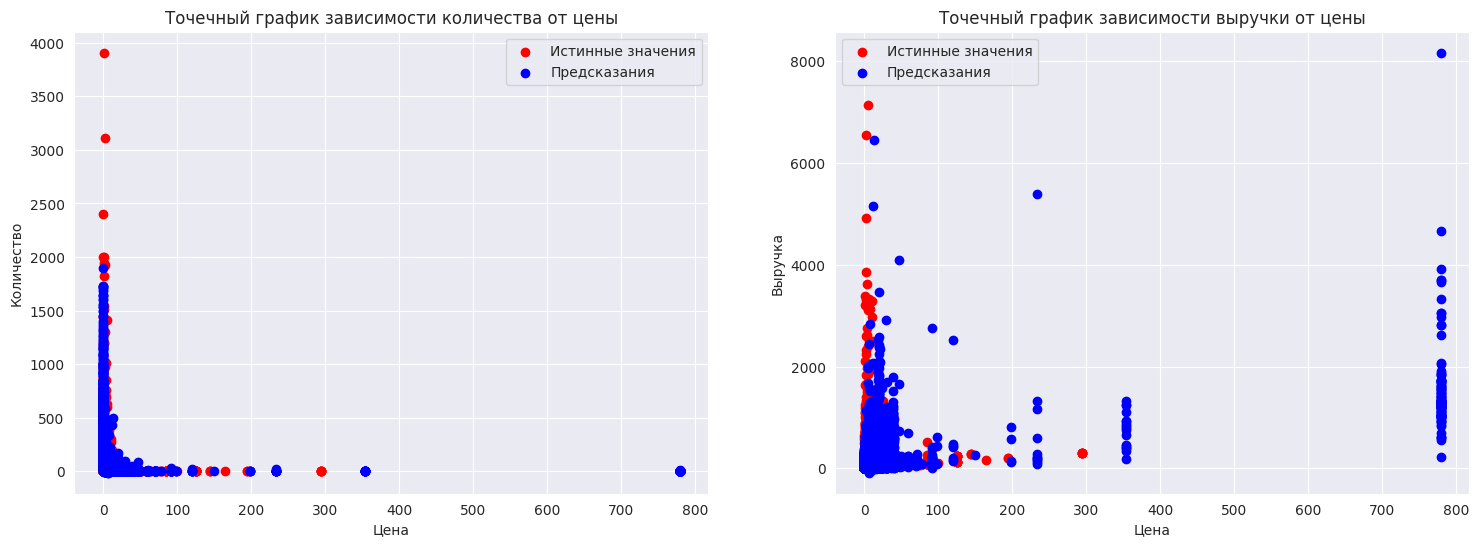

In [ ]:
plot_financial_plots(df_test_with_optimal_prices_catboost)

Видим, что распределения предсказнных и реальных характеристик схожи

## DML

Следующий алгоритм, который мы рассмотрим для решения поставленной задачи - это DML (Double Machine Learning). Для начала введём некоторые обозначения:
- $\large{Y}$ - целевая переменная (в нашем случае это количество приобретённого товара)
- $\large{T}$ - воздействие, то есть наблюдаемая цена
- $\large{W}$ - конфузоры, то есть факторы контекста, которые влияют и на цену $\large{T}$, и на целевую переменную $\large{Y}$ (например, время покупки, погода, акции конкурентов)
- $\large{X}$ - модифкаторы, то есть характеристики, от которых зависит чувствительность клиентуры к цене (категория товара, сегмент покупателя, регион)
- $\large{\theta(X)}$ - эластичность, то есть истинный чистый эффект, насколько изменится спрос $\large{Y}$, если поднять цену $\large{T}$ на одну условную единицу для объекта с признаками $\large{X}$
- $\large{\hat{Y}, \hat{T}}$ - предсказания моделей
- $\large{\widetilde{Y}, \widetilde{T}}$ - остатки/невязки

В реальных данных цена $\large{T}$ связана со спросом $\large{Y}$ через конфузоры $\large{W}$ и модификаторы $\large{X}$, поэтому если просто обучить модель по цене $\large{T}$ предсказывать спрос $\large{Y}$, то она может выучить ложную корреляцию, когда в отдельных случаях при высокой цене более высокий спрос (например в праздники), поэтому необходимо вычленить чистый эффект цены $\large{\theta}$, убрав влияние $\large{W}$ и $\large{X}$

Процесс обучения DML состоит из 3 основных шагов:
1. На конфузорах и модификаторах обучаются 2 независимые модели предсказывать цену $\large{T}$ и спрос $\large{Y}$:
   - Модель $\large{M_Y(X,W)}$ учится предсказывать спрос $\large{Y}$ только по $\large{X}$ и $\large{W}$ без учёта цены $\large{T}$:
   $$\large{\hat{Y}=M_Y(X,W)}$$

   - Модель $\large{M_T(X,W)}$ учится предсказывать цену $\large{T}$ только по $\large{X}$ и $\large{W}$:
   $$\large{\hat{T}=M_T(X,W)}$$

2. После предсказания высчитываются остатки (разности между реальными ценами и предсказанными):
$$\large{\begin{cases}\widetilde{Y}=Y-\hat{Y}=Y-M_Y(X,W) \\ \widetilde{T}=T-\hat{T}=T-M_T(X,W\end{cases}}$$
   Делается это для того, чтобы стереть влияние $\large{X}$ и $\large{W}$ на $\large{Y}$ и $\large{T}$, в которых теперь нет экзогенности

3. Далее DML строит третью модель, которая связывает $\large{\widetilde{Y}}$ и $\large{\widetilde{T}}$ через причинно-следственное уравнение:
$$\large{\widetilde{Y}=\theta(X)\cdot\widetilde{T}}$$
   Можно заметить, что здесь уже нет конфузоров $\large{W}$

   Мы будем исользовать непараметрический DML и для него будет минимизироваться среднеквадратичная ошибка между истинной переменной и предсказаниями:
   $$\large{\mathbb{E}\left[\left(\widetilde{Y}-\theta(X)\cdot\widetilde{T}\right)^2\right] \rightarrow \min}$$

   Эту задачу можно переписать в следующем виде:
   $$\large{\mathbb{E}\left[\widetilde{T}^2\left(\frac{\widetilde{Y}}{\widetilde{T}}-\theta(X)\right)^2\right] \rightarrow \min}$$

   То есть задача теперь формулируется как обычная задача регрессии на таргет $\large{\frac{\widetilde{Y}}{\widetilde{T}}}$, где каждый объект имеет вес $\large{\widetilde{T}^2}$

Далее очень важный шаг (кросс-фитинг) - если $\large{M_Y}$ и $\large{M_T}$ обучить на всех тех же данных, на которых потом считаем $\large{\widetilde{Y}}$ и $\large{\widetilde{T}}$ — модели переобучатся и "случайно" объяснят часть шума, который на самом деле связан с $\large{T}$. Это создаст смещение $\large{\theta}$ к нулю

То сь нужнот разделить данные на $\large{K}$ фолдов и для каждого фолда $\large{k}$:
1. Модели $\large{M_Y}$ и $\large{M_T}$ на всех фолдах кроме $\large{k}$
2. Считем $\large{\widetilde{Y}}$ и $\large{\widetilde{T}}$ только для наблюдений из фолда $\large{k}$, используя модель, которая не видела эти данные

Можно записать формулу предсказания спроса $\large{Y}$ по цене $\large{T}$:
$$\large{Y(T) = \underbrace{M_Y(X, W)}_{\text{Базовый спрос}} + \underbrace{\theta(X)}_{\text{Чистый наклон}} \cdot \Big( \underbrace{T}_{\text{Новая цена}} - \underbrace{M_T(X, W)}_{\text{Базовая цена}} \Big)}$$

То есть берётся базовый спрос $\large{M_Y}$ и корректируется в зависимости от того, насколько новая цена $\large{T}$ отличается от базовой цены $\large{M_T}$. Цена при этом умножается на эластичность $\large{\theta(X)}$

Теперь о главном преимуществе данного подхода по сравнению с предыдущим - не нужно составлять сетку цен-кандидатов и для каждой из них высчитывать спрос и выручку, ведь здесь оптимальную цену можно вывести аналитически

Итак, выручка равна произведению цены $\large{T}$ и спроса $\large{Y(T)}$:

$$\large{R(T)=T\cdot Y(T)=T\cdot\left[M_Y(X,W)+\theta(X)\cdot\left(T-M_T(X,W)\right)\right]}$$

Далее берём производную выручки по цене и приравниаем к нулю:

$$\large{\frac{\partial R(T)}{\partial T}=M_Y(X,W) + 2\theta(X)\cdot T - \theta(X)\cdot M_T(X,W)=0}$$

Отсюда находим оптимальную цену:

$$\large{T^{\ast}=\frac{M_T(X,W)}{2}-\frac{M_Y(X,W)}{2\theta(X)}}$$

Однако помня, что алгоритмы машинного обучения неидеальны, то я сделал несколько искусстенных ограничений:
1. Коэффициент эластичности сделаем не больше некого не очень большого по модулю отрицательного числа:
$$\large{\theta \leftarrow \min(\theta, \epsilon)}$$
2. Цена не должна изменяться очень сильно по сравнению с изначальной ценой $\large{P}$:

   $$\large{P\cdot(1 - g) \leq P^{\ast} \leq P\cdot(1 + g),}$$
   где $\large{g}$ - некий не очень больший коэффициент



К сожалению, модели из библиотеки econml не позволяют передавать категориальные признаки во внутернние модели, поэтому необходимо закодировать категориальыне столбцы по цене с помощью CatBoost-кодировщика

In [ ]:
encoder = CatBoostEncoder()
X_train[categorical_features] = encoder.fit_transform(
    X_train[categorical_features],
    X_train['UnitPrice']
)
X_valid[categorical_features] = encoder.transform(X_valid[categorical_features])
X_test[categorical_features] = encoder.transform(X_test[categorical_features])

Дальше выделим конфузоры и модификаторы

In [ ]:
X_columns = [
    'Category',
    'SinMonth',
    'IsInvoiceDateHoliday',
    'IsInvoiceDateWeekend',
    'StockCode'
]
W_columns = [
    'CustomerID',
    'InvoiceNo',
    'SinMinute'
]
train_T, valid_T, test_T = (
    X_train['UnitPrice'],
    X_valid['UnitPrice'],
    X_test['UnitPrice']
)
train_X, valid_X, test_X = (
    X_train[X_columns],
    X_valid[X_columns],
    X_test[X_columns]
)
train_W, valid_W, test_W = (
    X_train[W_columns],
    X_valid[W_columns],
    X_test[W_columns]
)
train_full, valid_full, test_full = (
    pd.concat([train_X, train_W], axis=1),
    pd.concat([valid_X, valid_W], axis=1),
    pd.concat([test_X, test_W], axis=1)
)

Так как $\large{M_Y}$, $\large{M_T}$ и финальная модель - CatBoostRegressor, то тут тоже можно попробовать подобрать оптимальные гиперпараметры

Оптимизируемая матрика при этом - среднеквадратичная ошибка между истинныи $\large{\widetilde{Y}}$ и предсказанными $\large{\theta(X)\cdot\widetilde{T}}$ значениями

In [ ]:
def objective_DML(trial, cv=3, **default_params):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    catboost_model = CatBoostRegressor(**param_distributions, **default_params)
    dml_model = NonParamDML(
        model_y=catboost_model,
        model_t=catboost_model,
        model_final=catboost_model,
        cv=cv
    )
    dml_model.fit(Y=y_train, T=train_T, X=train_X , W=train_W)
    value = dml_model.score(Y=y_valid, T=valid_T, X=valid_X , W=valid_W)
    return value

def optimize_DML(n_trials=20, cv=3, **default_params):
    study = create_study(
        direction='minimize',
        sampler=TPESampler(seed=random_state),
        study_name=f'Оптимизация алгоритма DML'
    )
    set_verbosity(WARNING)
    study.optimize(
        lambda trial: objective_DML(trial, cv=cv, **default_params),
        show_progress_bar=True,
        n_trials=n_trials
    )
    catboost_model = CatBoostRegressor(**study.best_params, **default_params)
    dml_model = NonParamDML(
        model_y=catboost_model,
        model_t=catboost_model,
        model_final=catboost_model,
        cv=cv
    )
    dml_model.fit(Y=y_train, T=train_T, X=train_X, W=train_W)
    return dml_model

In [ ]:
dml_model = optimize_DML(
    n_trials=20,
    verbose=False,
    random_state=random_state
)

  0%|          | 0/20 [00:00<?, ?it/s]

Механизм нахождения оптимальнйо цены был описа выше

Стоит отметить, что так как теперь нет сетки цен-кандидиатов и не нужно гонять модель каждый раз для предсказания споса по ценам, то предсказания считаются практически мгновенно

In [ ]:
def predict_optimal_price_dml(
    dml_model,
    X,
    full,
    epsilon=-5e-2,
    max_price_range=0.3
):
    base_quantity = dml_model.models_y[0][0].predict(full)
    base_price = dml_model.models_t[0][0].predict(full)
    theta = np.minimum(dml_model.const_marginal_effect(X), epsilon)
    raw_optimal_price = base_price / 2 - base_quantity / (2 * theta)
    optimal_price = np.clip(
        raw_optimal_price,
        base_price * (1 - max_price_range),
        base_price * (1 + max_price_range)
    )
    optimal_quantity = np.maximum(
        base_quantity + theta * (optimal_price - base_price), 0
    )
    return optimal_quantity, optimal_price

Предскажем оптимальные цены

In [ ]:
df_test_with_optimal_prices_dml = df_test.copy()
quantities, optimal_prices = predict_optimal_price_dml(
    dml_model,
    test_X,
    test_full
)
df_test_with_optimal_prices_dml.insert(
    df.columns.get_loc('UnitPrice') + 1,
    'OriginalUnitPrice',
    df_test_with_optimal_prices_dml['UnitPrice'].values
)
df_test_with_optimal_prices_dml.insert(
    df.columns.get_loc('Quantity') + 1,
    'OriginalQuantity',
    df_test_with_optimal_prices_dml['Quantity'].values
)
df_test_with_optimal_prices_dml['Quantity'] = quantities
df_test_with_optimal_prices_dml['UnitPrice'] = optimal_prices

In [ ]:
mean_revenue, median_percent_revenue = calculate_revenue_stats(
    df_test_with_optimal_prices_dml
)
print(f'{mean_revenue=}, {median_percent_revenue=}')

mean_revenue=8.041478728125275, median_percent_revenue=74.92582224750373


Видим, что здесь выручка поменьше, что может говорить как о менее хорошем качестве модлей, так и о её большей реалистичности

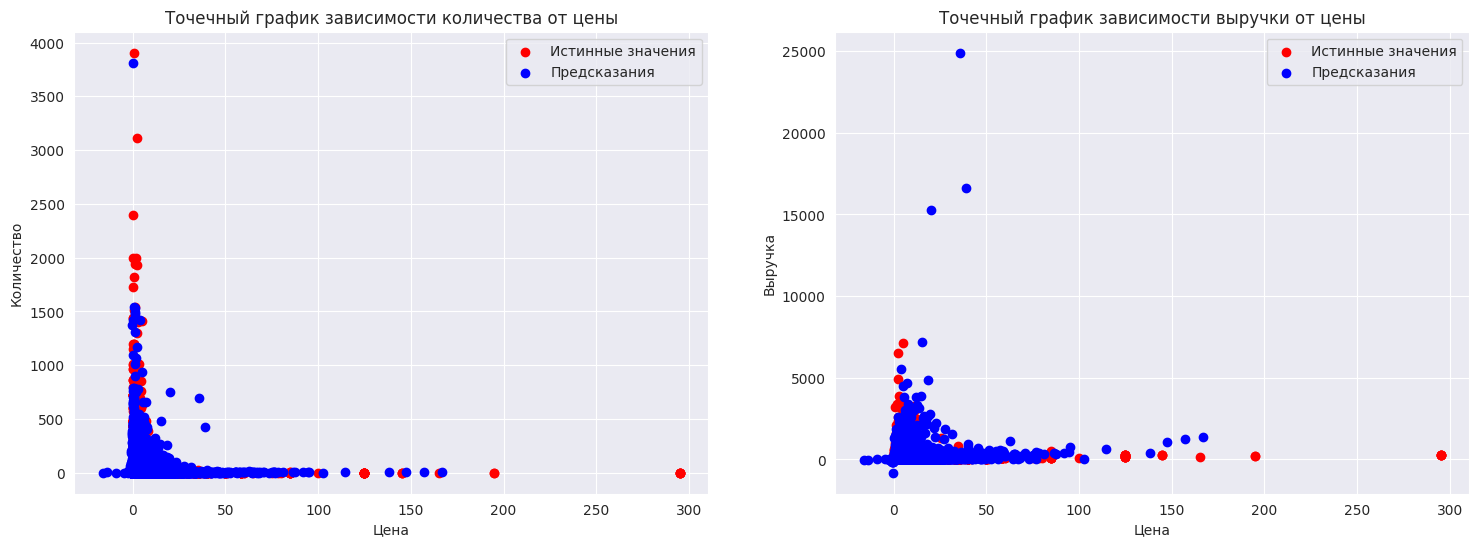

In [ ]:
plot_financial_plots(df_test_with_optimal_prices_dml)

Распределения вновь довольно схожи друг с другом

# Выводы

В данной работе были попробованы основы динамического ценообразования и были испробованы следующие модели:
- CatBoost для предсказания количества + сетка цен-кандидатов
- DML с предсказанием оптимальной цены

По предсказанной выручке лучше оказалась первая модель